In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid') 


 

In [2]:
import os
os.listdir("../data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Veri seti boyutu (satır, sütun):", df.shape)
df.info()

Veri seti boyutu (satır, sütun): (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperless

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [7]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [8]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("TotalCharges'ta eksik değer sayısı:", df['TotalCharges'].isnull().sum())

TotalCharges'ta eksik değer sayısı: 0


In [10]:
cat_cols = [col for col in df.columns if pd.api.types.is_string_dtype(df[col]) and col != 'customerID']
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Kategorik değişkenler:", cat_cols)
print("\nSayısal değişkenler:", num_cols)

Kategorik değişkenler: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Sayısal değişkenler: ['tenure', 'MonthlyCharges', 'TotalCharges']


In [11]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn'].mean().sort_values(ascending=False))


--- gender ---
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

--- Partner ---
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

--- Dependents ---
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64

--- MultipleLines ---
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name: Churn, dtype: float64

--- DeviceProtection ---

In [12]:
df.groupby('Churn')[num_cols].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.569965,61.265124,2549.911442
1,17.979133,74.441332,1531.796094


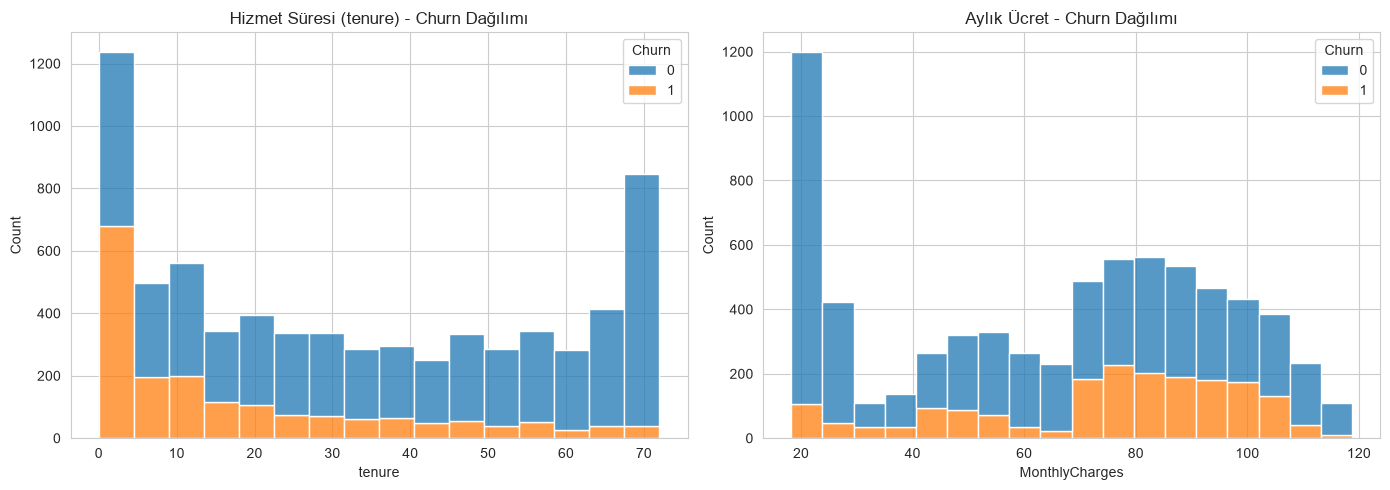

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0])
axes[0].set_title('Hizmet Süresi (tenure) - Churn Dağılımı')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Aylık Ücret - Churn Dağılımı')
plt.tight_layout()
plt.savefig('../gorseller/tenure_monthlycharges_churn.png', dpi=100)
plt.show()

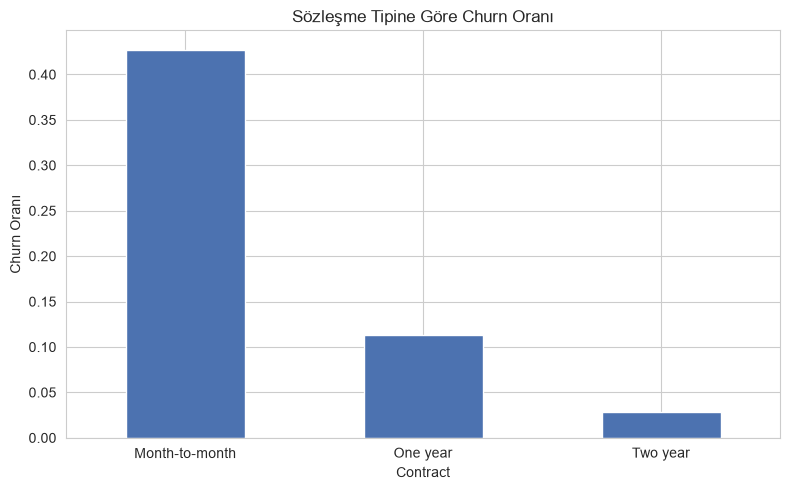

In [14]:
plt.figure(figsize=(8, 5))
df.groupby('Contract')['Churn'].mean().plot(kind='bar', color='#4C72B0')
plt.title('Sözleşme Tipine Göre Churn Oranı')
plt.ylabel('Churn Oranı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../gorseller/contract_churn_orani.png', dpi=100)
plt.show()

In [15]:
df_model = df.drop('customerID', axis=1)

binary_cols = [col for col in cat_cols if df_model[col].nunique() == 2]
multi_cols = [col for col in cat_cols if df_model[col].nunique() > 2]

print("İkili değişkenler:", binary_cols)
print("Çok kategorili değişkenler:", multi_cols)

İkili değişkenler: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Çok kategorili değişkenler: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)
print("Yeni veri seti boyutu:", df_model.shape)
df_model.head()

Yeni veri seti boyutu: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [17]:

from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)
print("\nEğitimde churn oranı:", y_train.mean().round(3))
print("Testte churn oranı:", y_test.mean().round(3))

Eğitim seti: (5634, 30)
Test seti: (1409, 30)

Eğitimde churn oranı: 0.265
Testte churn oranı: 0.265


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.262257,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.503635,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.749883,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.172722,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.989374,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

In [20]:
print("=== Logistic Regression - Test Sonuçları ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 3))
print("Precision:", round(precision_score(y_test, y_pred_log), 3))
print("Recall   :", round(recall_score(y_test, y_pred_log), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_log), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_log), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

=== Logistic Regression - Test Sonuçları ===
Accuracy : 0.806
Precision: 0.659
Recall   : 0.559
F1 Score : 0.605
ROC-AUC  : 0.842

Confusion Matrix:
[[927 108]
 [165 209]]


In [21]:
train_acc_log = accuracy_score(y_train, log_reg.predict(X_train))
test_acc_log = accuracy_score(y_test, y_pred_log)

print(f"Eğitim accuracy: {train_acc_log:.3f}")
print(f"Test accuracy  : {test_acc_log:.3f}");

Eğitim accuracy: 0.806
Test accuracy  : 0.806


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [23]:
print("=== Random Forest - Test Sonuçları ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_rf), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nEğitim accuracy: {train_acc_rf:.3f}")
print(f"Test accuracy  : {test_acc_rf:.3f}")

=== Random Forest - Test Sonuçları ===
Accuracy : 0.806
Precision: 0.67
Recall   : 0.527
F1 Score : 0.59
ROC-AUC  : 0.841

Confusion Matrix:
[[938  97]
 [177 197]]

Eğitim accuracy: 0.866
Test accuracy  : 0.806


In [24]:
from sklearn.model_selection import cross_val_score

cv_log = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='f1')
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

print("Logistic Regression CV F1 skorları:", cv_log.round(3))
print("Ortalama:", cv_log.mean().round(3), "  Std:", cv_log.std().round(3))

print("\nRandom Forest CV F1 skorları:", cv_rf.round(3))
print("Ortalama:", cv_rf.mean().round(3), "  Std:", cv_rf.std().round(3))

Logistic Regression CV F1 skorları: [0.653 0.581 0.597 0.579 0.581]
Ortalama: 0.598   Std: 0.028

Random Forest CV F1 skorları: [0.604 0.588 0.559 0.545 0.546]
Ortalama: 0.569   Std: 0.024


In [25]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_rf)],
})
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.806,0.659,0.559,0.605,0.842
1,Random Forest,0.806,0.670,0.527,0.590,0.841


In [26]:
log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_bal.fit(X_train, y_train)
y_pred_log_bal = log_reg_bal.predict(X_test)
y_proba_log_bal = log_reg_bal.predict_proba(X_test)[:, 1]

rf_bal = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_bal.fit(X_train, y_train)
y_pred_rf_bal = rf_bal.predict(X_test)
y_proba_rf_bal = rf_bal.predict_proba(X_test)[:, 1]

comparison_bal = pd.DataFrame({
    'Model': ['Logistic Regression (balanced)', 'Random Forest (balanced)'],
    'Accuracy': [accuracy_score(y_test, y_pred_log_bal), accuracy_score(y_test, y_pred_rf_bal)],
    'Precision': [precision_score(y_test, y_pred_log_bal), precision_score(y_test, y_pred_rf_bal)],
    'Recall': [recall_score(y_test, y_pred_log_bal), recall_score(y_test, y_pred_rf_bal)],
    'F1': [f1_score(y_test, y_pred_log_bal), f1_score(y_test, y_pred_rf_bal)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_log_bal), roc_auc_score(y_test, y_proba_rf_bal)],
})

pd.concat([comparison, comparison_bal]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.806,0.659,0.559,0.605,0.842
1,Random Forest,0.806,0.670,0.527,0.590,0.841
0,Logistic Regression (balanced),0.738,0.504,0.783,0.614,0.842
1,Random Forest (balanced),0.765,0.540,0.775,0.637,0.840


In [27]:
train_acc_rf_bal = accuracy_score(y_train, rf_bal.predict(X_train))
test_acc_rf_bal = accuracy_score(y_test, y_pred_rf_bal)
print(f"Random Forest (balanced) - Eğitim accuracy: {train_acc_rf_bal:.3f}")
print(f"Random Forest (balanced) - Test accuracy  : {test_acc_rf_bal:.3f}")

Random Forest (balanced) - Eğitim accuracy: 0.851
Random Forest (balanced) - Test accuracy  : 0.765


In [28]:
import os
import joblib

os.makedirs('../models', exist_ok=True)

joblib.dump(rf_bal, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X_train.columns), '../models/feature_columns.pkl')
joblib.dump(num_cols, '../models/num_cols.pkl')

print("Model ve yardımcı dosyalar kaydedildi.")

Model ve yardımcı dosyalar kaydedildi.


In [29]:
import shap

explainer = shap.TreeExplainer(rf_bal)
shap_values = explainer(X_test)

print("SHAP değerleri boyutu:", shap_values.shape)

C:\Users\minet\musteri-kaybi-projesi\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP değerleri boyutu: (1409, 30, 2)


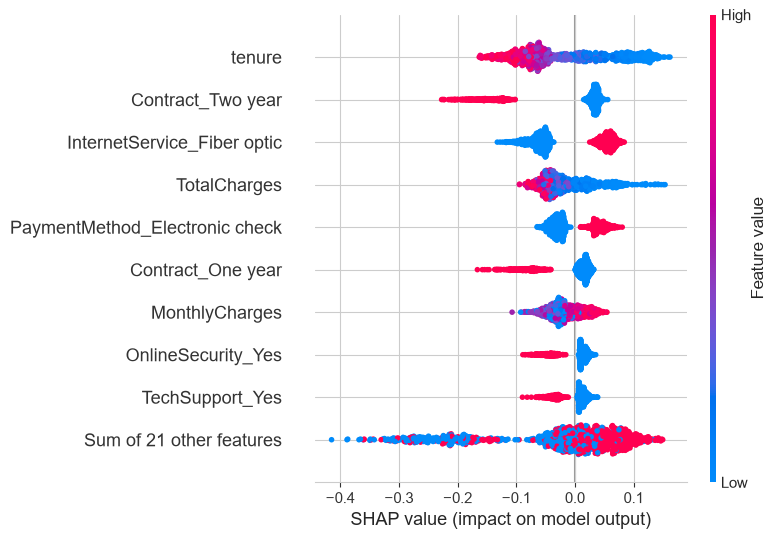

In [30]:
shap.plots.beeswarm(shap_values[:, :, 1], show=False)
plt.tight_layout()
plt.savefig('../gorseller/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

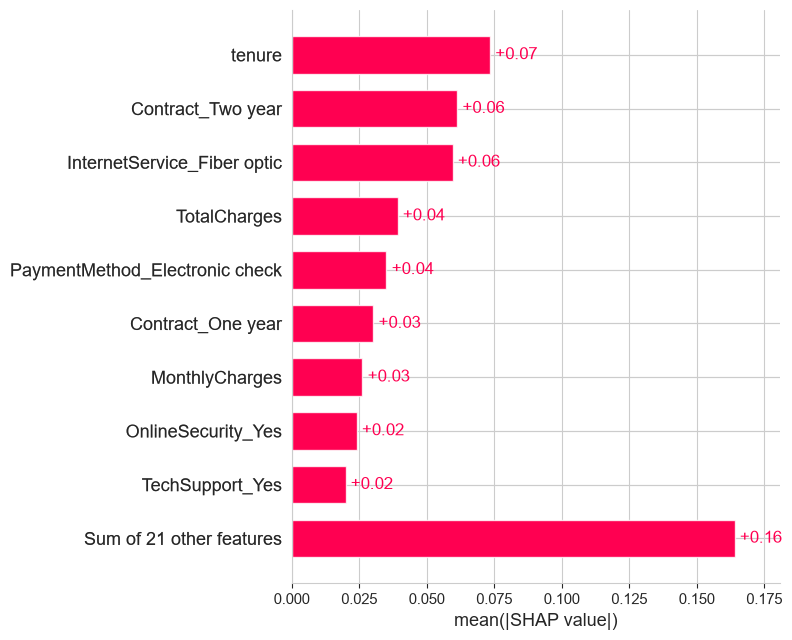

In [31]:
shap.plots.bar(shap_values[:, :, 1], show=False)
plt.tight_layout()
plt.savefig('../gorseller/shap_bar.png', dpi=100, bbox_inches='tight')
plt.show()

Müşteri index: 1109 | Gerçek durum (Churn): 1 | Tahmini risk olasılığı: 0.950


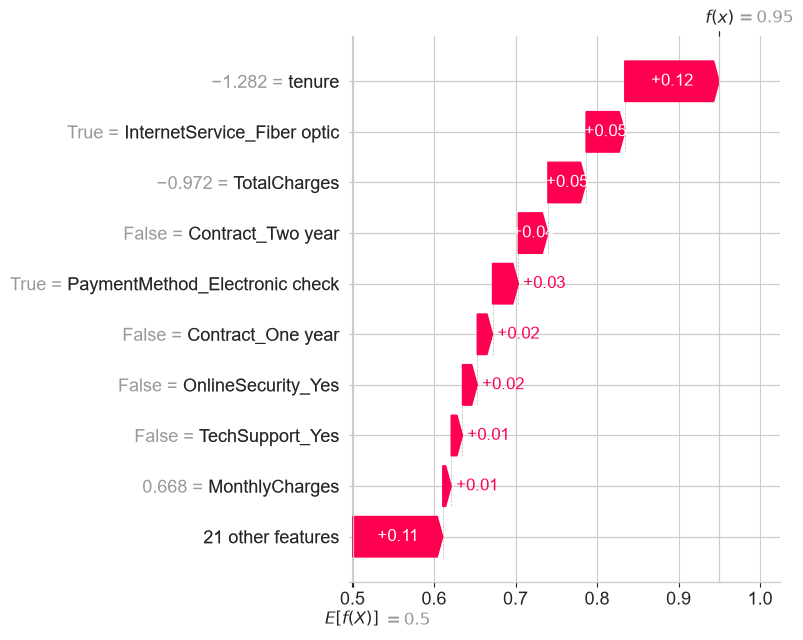

In [32]:
risky_idx = y_proba_rf_bal.argmax()
print(f"Müşteri index: {risky_idx} | Gerçek durum (Churn): {y_test.iloc[risky_idx]} | Tahmini risk olasılığı: {y_proba_rf_bal[risky_idx]:.3f}")

shap.plots.waterfall(shap_values[risky_idx, :, 1], show=False)
plt.tight_layout()
plt.savefig('../gorseller/shap_waterfall_riskli_musteri.png', dpi=100, bbox_inches='tight')
plt.show()

Müşteri index: 475 | Gerçek durum (Churn): 0 | Tahmini risk olasılığı: 0.000


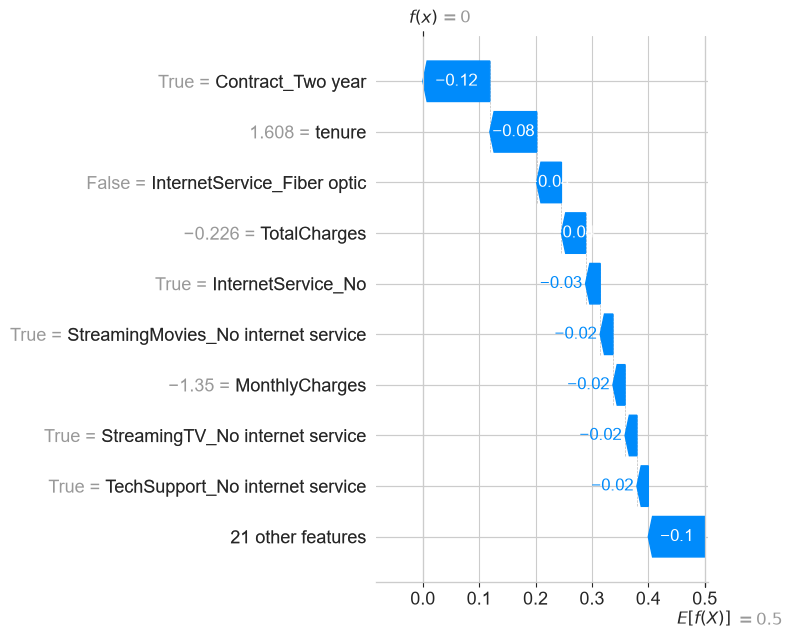

In [33]:
safe_idx = y_proba_rf_bal.argmin()
print(f"Müşteri index: {safe_idx} | Gerçek durum (Churn): {y_test.iloc[safe_idx]} | Tahmini risk olasılığı: {y_proba_rf_bal[safe_idx]:.3f}")

shap.plots.waterfall(shap_values[safe_idx, :, 1], show=False)
plt.tight_layout()
plt.savefig('../gorseller/shap_waterfall_dusuk_riskli_musteri.png', dpi=100, bbox_inches='tight')
plt.show()